In [3]:
# Install pytorch
%pip install torch
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 24.3 MB/s eta 0:00:0000:0100:01
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


## **Dataset Creation**

### Import libraries

In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset


In [1]:
# Import the groundtruth poses from the text file with the following format:
# timestamp tx ty tz qx qy qz qw

def load_groundtruth_poses(file_path):
    poses = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split()
            timestamp = float(parts[0])
            tx, ty, tz = map(float, parts[1:4])
            qx, qy, qz, qw = map(float, parts[4:8])
            poses.append((timestamp, tx, ty, tz, qx, qy, qz, qw))
    return poses

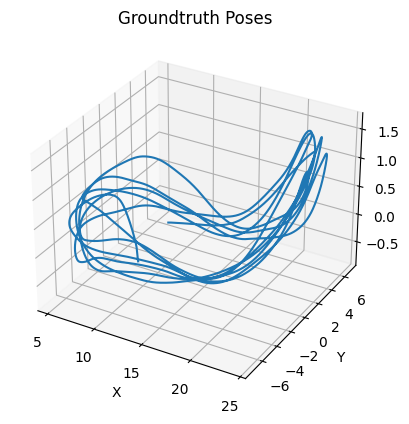

In [3]:
# Plot the groundtruth poses in 3D
def plot_groundtruth_poses(poses):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    xs = [pose[1] for pose in poses]
    ys = [pose[2] for pose in poses]
    zs = [pose[3] for pose in poses]
    ax.plot(xs, ys, zs)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title('Groundtruth Poses')
    plt.show()

# Example usage
file_path = 'Dataset/groundtruth.txt'  # Replace with your file path
poses = load_groundtruth_poses(file_path)
plot_groundtruth_poses(poses)

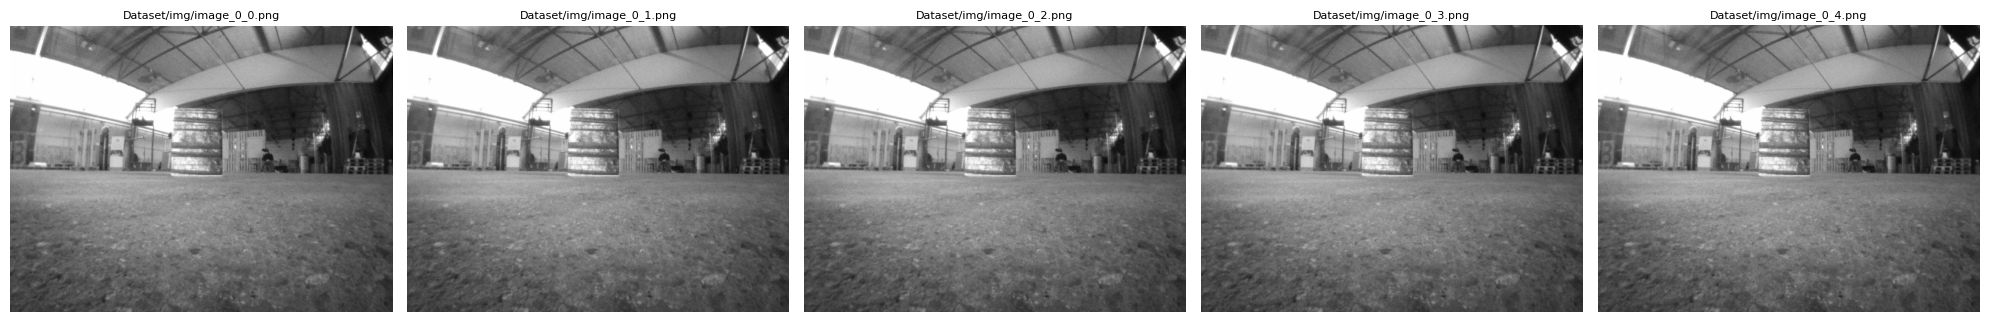

In [7]:
# Import the left stereo camera images and display a few samples
import cv2

# Extract the image path from the text file with the following format:
# id timestamp image_name
def load_image_paths(file_path):
    image_paths = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split()
            timestamp = float(parts[1])  # timestamp is column 1
            image_path = 'Dataset/' + parts[2]  # prepend Dataset/ to relative path
            image_paths.append(image_path)
    return image_paths

def load_and_display_images(image_paths, num_samples=5):
    fig = plt.figure(figsize=(num_samples * 4, 5))
    for i, image_path in enumerate(image_paths[:num_samples]):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Add the image name path for plotting as title for checking correctness
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(image_path, fontsize=8, wrap=True)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage
image_file_path = 'Dataset/left_images.txt'
image_paths = load_image_paths(image_file_path)
load_and_display_images(image_paths)